In [18]:
# load mcs-legnet and mcs-agft (full all-by-all swap libraries; identical seqs -> aligned pair order)
import numpy as np

RES = "/grid/koo/home/pmantill/projects/SEAM_validate/mcs_k562/results"
S  = np.load(f"{RES}/legnet_swap_full.npz", allow_pickle=True)   # MPRALegNet ensemble
SA = np.load(f"{RES}/agft_swap_full.npz",   allow_pickle=True)   # AlphaGenome-encoder-FT

assert np.array_equal(S["pair_donor"], SA["pair_donor"])
assert np.array_equal(S["pair_ctx"],   SA["pair_ctx"])
print("legnet swap", S["swap"].shape, "| agft swap", SA["swap"].shape)


legnet swap (506, 20) | agft swap (506, 20)


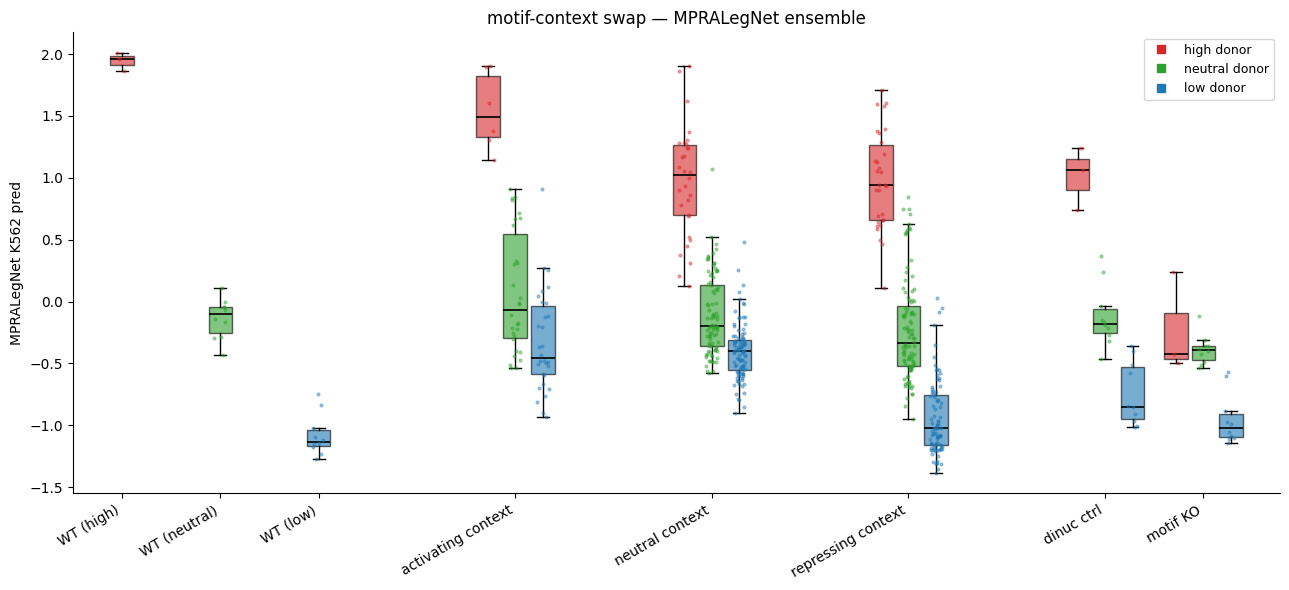

In [19]:
# pooled all-by-all: each context class holds three donor boxes (high=red, neutral=green, low=blue).
# each point = mean over the 20 reps for one (donor, context) pair. order: activating -> neutral -> repressing.
# MPRALegNet ensemble preds, from the full swap library (legnet_swap_full.npz).
import matplotlib.pyplot as plt

RED, GREEN, BLUE = "#d62728", "#2ca02c", "#1f77b4"
hi, neu, lo = list(S["high"]), list(S["neutral"]), list(S["low"])
swap_mean = S["swap"].mean(1)                                              # (506,) mean over 20 reps
smap = {(int(d), int(t)): swap_mean[k] for k, (d, t) in enumerate(zip(S["pair_donor"], S["pair_ctx"]))}
ctrl, pre, wt_all = S["ctrl"], S["pre"], S["wt_all"]

def cls_pool(donors, ctxs):
    return np.array([smap[(d, t)] for d in donors for t in ctxs if d != t])

CTX = [("activating context", hi, 4), ("neutral context", neu, 6), ("repressing context", lo, 8)]
DON = [(hi, RED, -0.28), (neu, GREEN, 0.0), (lo, BLUE, 0.28)]             # donor class -> color, dodge offset

boxes = [(np.array([wt_all[i] for i in hi]), 0, RED),                     # endogenous WT per class
         (np.array([wt_all[i] for i in neu]), 1, GREEN),
         (np.array([wt_all[i] for i in lo]), 2, BLUE)]
for _, ctxs, cx in CTX:
    for donors, dc, off in DON:
        boxes.append((cls_pool(donors, ctxs), cx + off, dc))
for cx, val in [(10, ctrl), (11, pre)]:                                   # controls split by donor class (dinuc ctrl | motif KO)
    for donors, dc, off in DON:
        boxes.append((np.array([val[d].mean() for d in donors]), cx + off, dc))
ticks  = [0, 1, 2] + [cx for _, _, cx in CTX] + [10, 11]
labels = ["WT (high)", "WT (neutral)", "WT (low)"] + [c for c, _, _ in CTX] + ["dinuc ctrl", "motif KO"]

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot([b[0] for b in boxes], positions=[b[1] for b in boxes], widths=0.24,
                patch_artist=True, showfliers=False, medianprops=dict(color="black", lw=1.2))
for patch, b in zip(bp["boxes"], boxes):
    patch.set_facecolor(b[2]); patch.set_alpha(0.6)
for data, x, c in boxes:
    ax.scatter(x + rng.uniform(-0.06, 0.06, len(data)), data, s=4, color=c, alpha=0.4, zorder=3)
ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend(handles=[plt.Line2D([], [], marker="s", color=RED, ls=""), plt.Line2D([], [], marker="s", color=GREEN, ls=""),
                   plt.Line2D([], [], marker="s", color=BLUE, ls="")],
          labels=["high donor", "neutral donor", "low donor"], loc="best", fontsize=9)
ax.set_ylabel("MPRALegNet K562 pred")
ax.set_title("motif-context swap — MPRALegNet ensemble")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(f"{RES}/mpralegnet_swap_pooled.png", dpi=300, bbox_inches="tight")


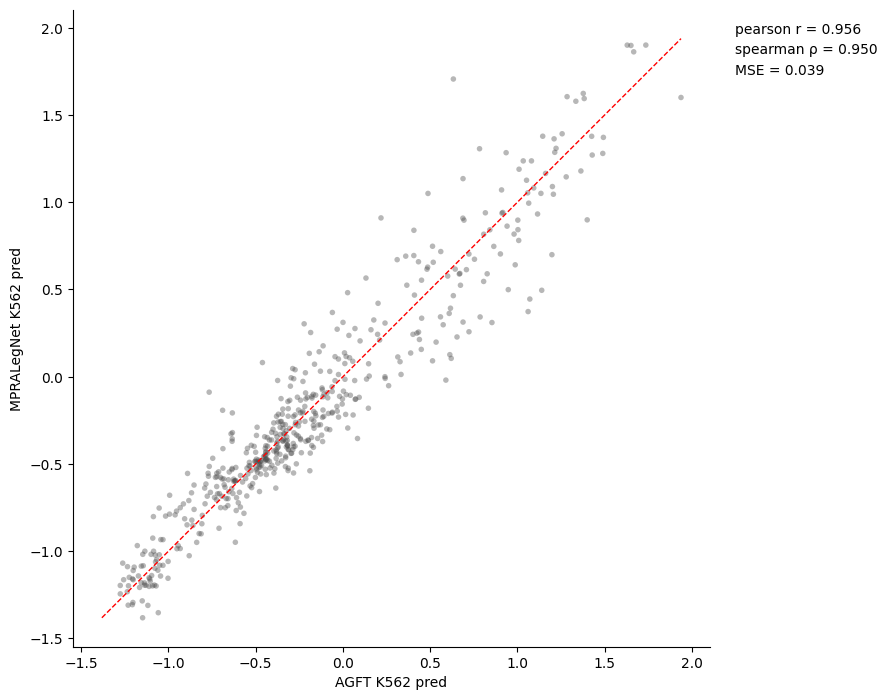

In [20]:
# single all-by-all scatter, MPRALegNet vs AGFT (one point per donor->context pair, mean over 20 reps)
from scipy.stats import pearsonr, spearmanr

lm = S["swap"].mean(1)          # (506,) MPRALegNet per-pair mean
am = SA["swap"].mean(1)         # (506,) AGFT per-pair mean
r   = pearsonr(lm, am)[0]
rho = spearmanr(lm, am)[0]
mse = np.mean((lm - am) ** 2)

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(am, lm, s=16, alpha=0.4, color="0.3", edgecolor="none")
lo, hi = min(am.min(), lm.min()), max(am.max(), lm.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set_xlabel("AGFT K562 pred")
ax.set_ylabel("MPRALegNet K562 pred")
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)

stats = [f"pearson r = {r:.3f}", f"spearman ρ = {rho:.3f}", f"MSE = {mse:.3f}"]
ax.legend([plt.Line2D([], [], ls="") for _ in stats], stats, loc="upper left",
          bbox_to_anchor=(1.02, 1.0), frameon=False, handlelength=0, handletextpad=0)
plt.tight_layout()
fig.savefig(f"{RES}/mpralegnet_vs_agft_scatter.png", dpi=300, bbox_inches="tight")
